In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/customer_shopping_behavior.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.shape

(3900, 18)

In [5]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [10]:
df["Category"].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [11]:
df["Gender"].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

In [12]:
df["Subscription Status"].value_counts()

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

In [13]:
df["Frequency of Purchases"].value_counts()

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

In [14]:
df.groupby("Category")["Review Rating"].median()

Category
Accessories    3.8
Clothing       3.7
Footwear       3.8
Outerwear      3.8
Name: Review Rating, dtype: float64

In [15]:
df["Review Rating"] = df.groupby("Category")["Review Rating"].transform(
    lambda x: x.fillna(x.median())
)

In [16]:
df["Review Rating"].isnull().sum()

np.int64(0)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [18]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [19]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

In [20]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [21]:
df.rename(
    columns={
        "purchase_amount_usd": "purchase_amount"
    },
    inplace=True
)

In [22]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [23]:
df.dtypes

customer_id                 int64
age                         int64
gender                        str
item_purchased                str
category                      str
purchase_amount             int64
location                      str
size                          str
color                         str
season                        str
review_rating             float64
subscription_status           str
shipping_type                 str
discount_applied              str
promo_code_used               str
previous_purchases          int64
payment_method                str
frequency_of_purchases        str
dtype: object

In [24]:
pd.crosstab(
    df["discount_applied"],
    df["promo_code_used"]
)

promo_code_used,No,Yes
discount_applied,,
No,2223,0
Yes,0,1677


In [25]:
df.drop(columns=["promo_code_used"], inplace=True)

In [26]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='str')

In [27]:
def age_group(age):
    if age <= 25:
        return "Young Adult"
    elif age <= 35:
        return "Adult"
    elif age <= 50:
        return "Middle-aged"
    else:
        return "Senior"

df["age_group"] = df["age"].apply(age_group)

In [28]:
df["age_group"].value_counts()

age_group
Senior         1476
Middle-aged    1111
Adult           742
Young Adult     571
Name: count, dtype: int64

In [29]:
frequency_mapping = {
    "Weekly": 7,
    "Bi-Weekly": 14,
    "Fortnightly": 14,
    "Monthly": 30,
    "Every 3 Months": 90,
    "Quarterly": 90,
    "Annually": 365
}

In [30]:
df["purchase_frequency_days"] = (
    df["frequency_of_purchases"].map(frequency_mapping)
)

In [31]:
df[
    [
        "frequency_of_purchases",
        "purchase_frequency_days"
    ]
].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [32]:
df["purchase_frequency_days"].isnull().sum()

np.int64(0)

In [33]:
df.shape

(3900, 19)

In [34]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount            0
location                   0
size                       0
color                      0
season                     0
review_rating              0
subscription_status        0
shipping_type              0
discount_applied           0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
age_group                  0
purchase_frequency_days    0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Senior,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              3900 non-null   int64  
 1   age                      3900 non-null   int64  
 2   gender                   3900 non-null   str    
 3   item_purchased           3900 non-null   str    
 4   category                 3900 non-null   str    
 5   purchase_amount          3900 non-null   int64  
 6   location                 3900 non-null   str    
 7   size                     3900 non-null   str    
 8   color                    3900 non-null   str    
 9   season                   3900 non-null   str    
 10  review_rating            3900 non-null   float64
 11  subscription_status      3900 non-null   str    
 12  shipping_type            3900 non-null   str    
 13  discount_applied         3900 non-null   str    
 14  previous_purchases       3900 non-n

In [38]:
df.to_csv(
    "../data/customer_shopping_behavior_cleaned.csv",
    index=False
)

In [39]:
import os

os.path.exists("../data/customer_shopping_behavior_cleaned.csv")

True

In [40]:
cleaned_check = pd.read_csv(
    "../data/customer_shopping_behavior_cleaned.csv"
)

In [41]:
cleaned_check.shape

(3900, 19)

In [42]:
cleaned_check.isnull().sum().sum()

np.int64(0)

In [43]:
df.to_csv(
    "../data/customer_shopping_behavior_cleaned.csv",
    index=False
)

In [44]:
import os
os.path.exists("../data/customer_shopping_behavior_cleaned.csv")

True

In [45]:
cleaned_check = pd.read_csv(
    "../data/customer_shopping_behavior_cleaned.csv"
)

cleaned_check.shape

(3900, 19)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../data/customer_shopping_behavior_cleaned.csv")

print(df.shape)
df.head()

(3900, 19)


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Senior,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


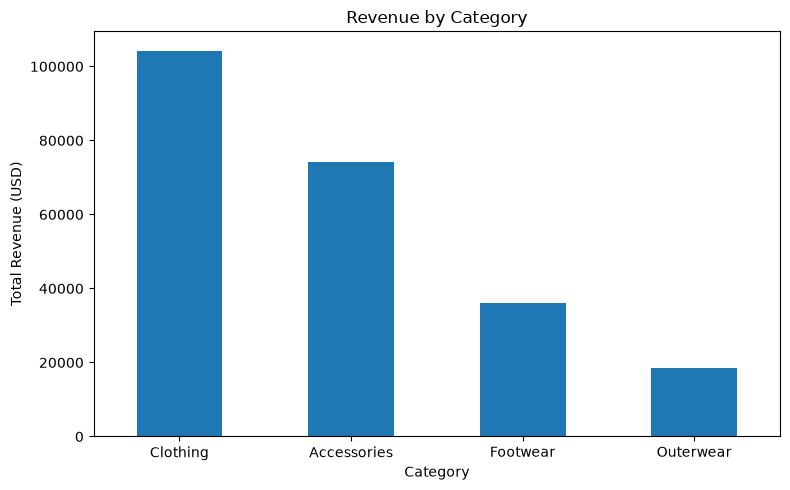

In [47]:
category_revenue = (
    df.groupby("category")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()

os.makedirs("../screenshots", exist_ok=True)
plt.savefig("../screenshots/revenue_by_category.png", dpi=300)

plt.show()

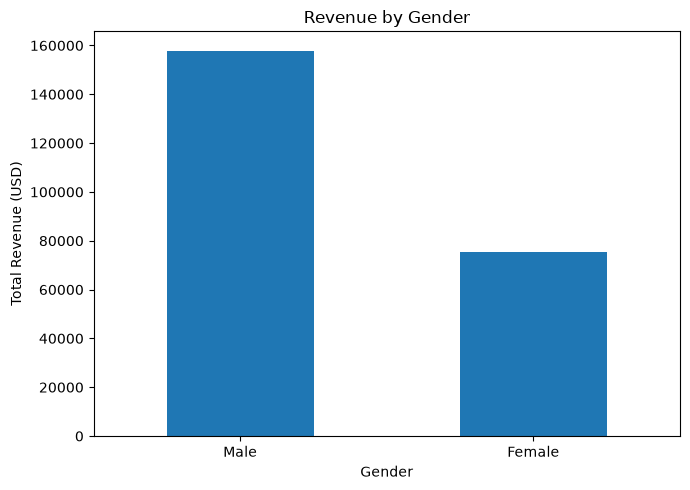

In [48]:
gender_revenue = (
    df.groupby("gender")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

gender_revenue.plot(kind="bar")

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../screenshots/revenue_by_gender.png", dpi=300)

plt.show()

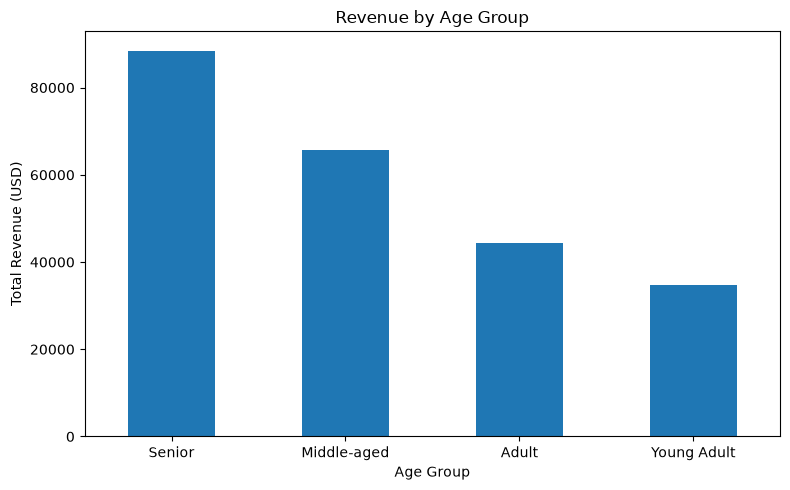

In [49]:
age_group_revenue = (
    df.groupby("age_group")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

age_group_revenue.plot(kind="bar")

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../screenshots/revenue_by_age_group.png", dpi=300)

plt.show()

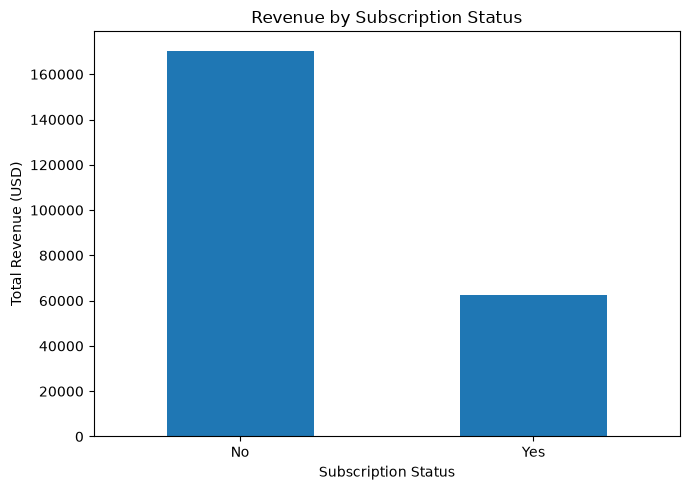

In [50]:
subscription_revenue = (
    df.groupby("subscription_status")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

subscription_revenue.plot(kind="bar")

plt.title("Revenue by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../screenshots/revenue_by_subscription.png", dpi=300)

plt.show()

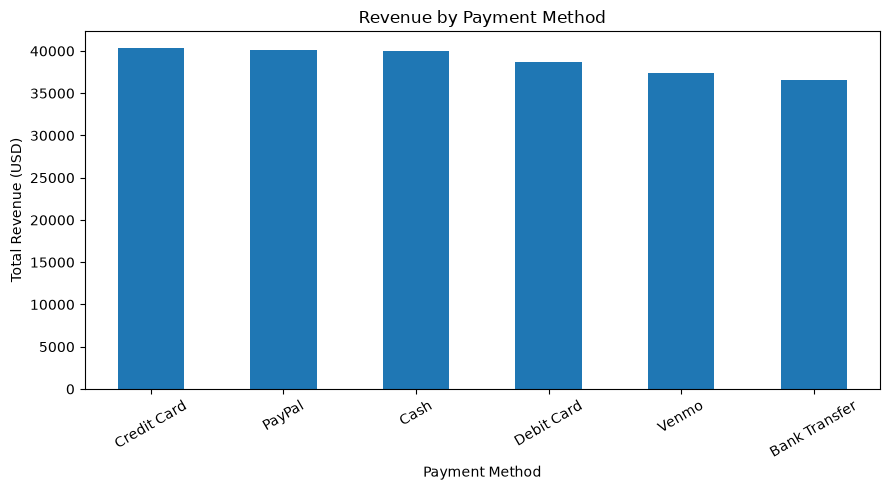

In [51]:
payment_revenue = (
    df.groupby("payment_method")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

payment_revenue.plot(kind="bar")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("../screenshots/revenue_by_payment_method.png", dpi=300)

plt.show()

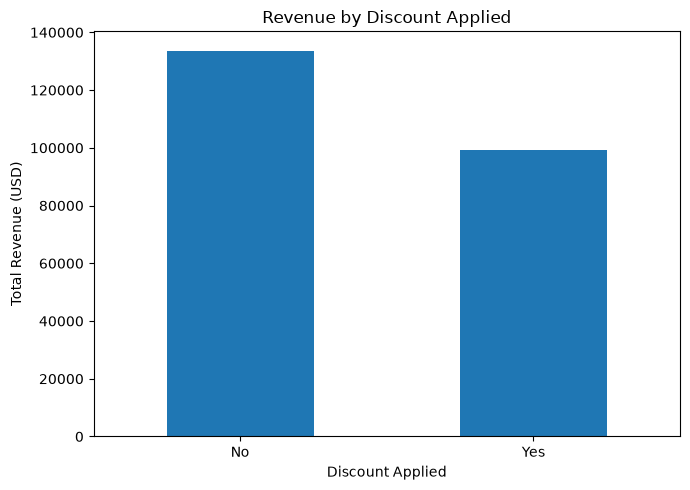

In [52]:
discount_revenue = (
    df.groupby("discount_applied")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

discount_revenue.plot(kind="bar")

plt.title("Revenue by Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../screenshots/revenue_by_discount.png", dpi=300)

plt.show()

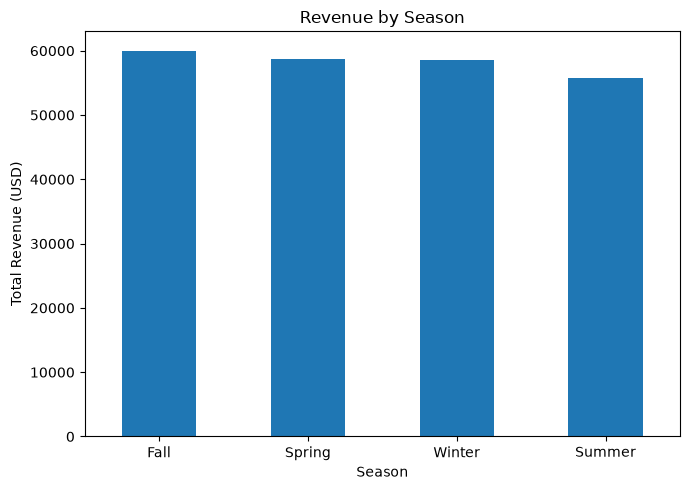

In [53]:
season_revenue = (
    df.groupby("season")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

season_revenue.plot(kind="bar")

plt.title("Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../screenshots/revenue_by_season.png", dpi=300)

plt.show()

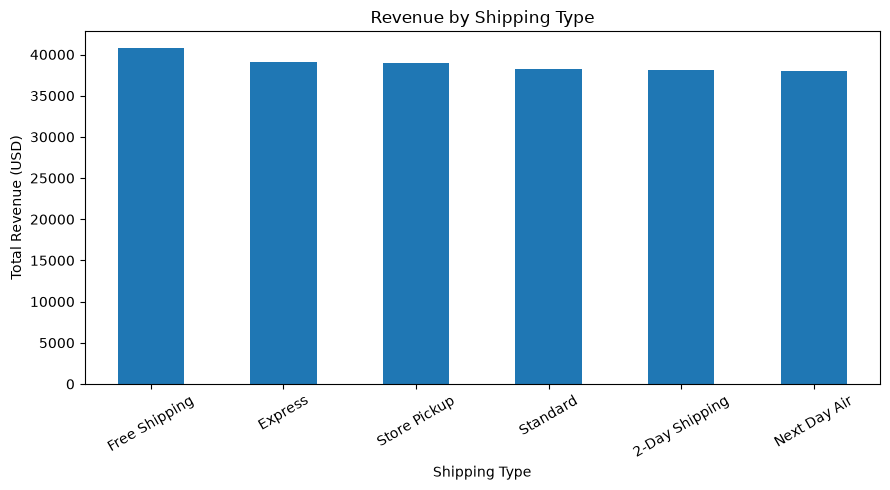

In [54]:
shipping_revenue = (
    df.groupby("shipping_type")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

shipping_revenue.plot(kind="bar")

plt.title("Revenue by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("../screenshots/revenue_by_shipping_type.png", dpi=300)

plt.show()

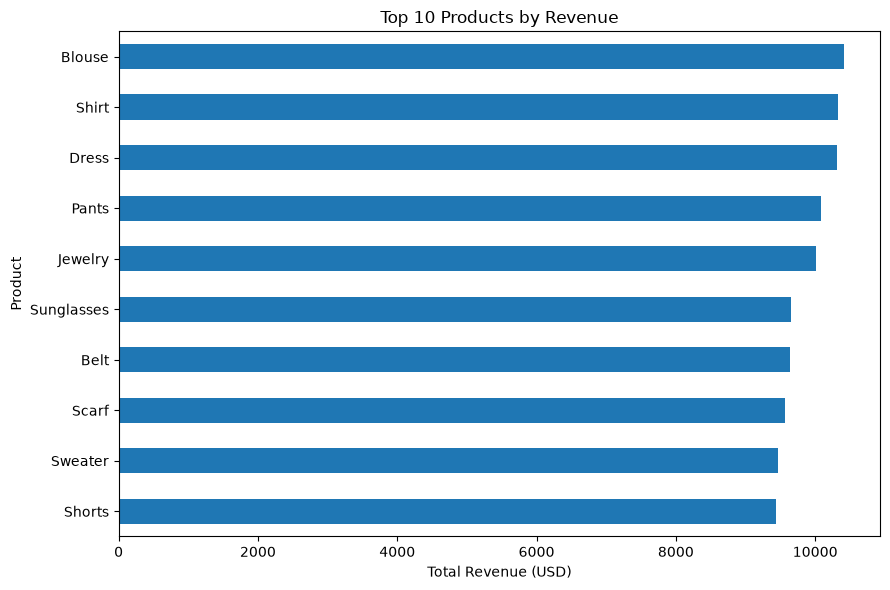

In [55]:
top_products = (
    df.groupby("item_purchased")["purchase_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue (USD)")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig("../screenshots/top_10_products_by_revenue.png", dpi=300)

plt.show()

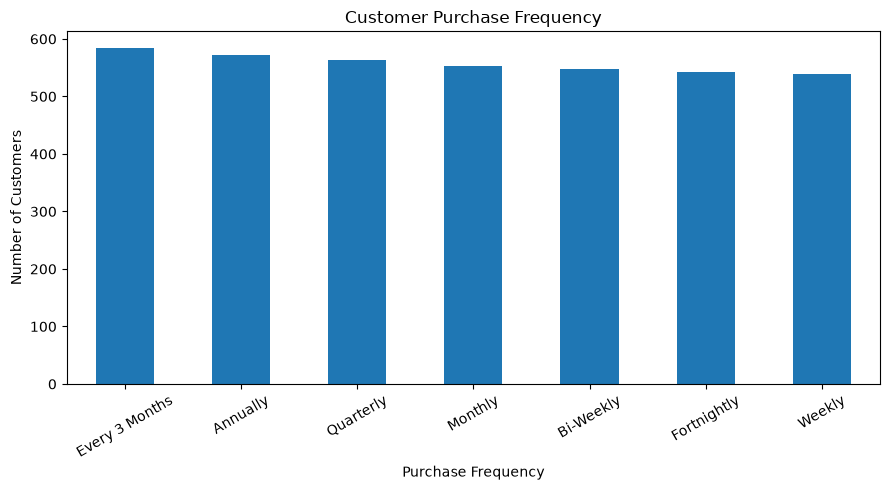

In [56]:
frequency_counts = (
    df["frequency_of_purchases"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

frequency_counts.plot(kind="bar")

plt.title("Customer Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("../screenshots/purchase_frequency.png", dpi=300)

plt.show()

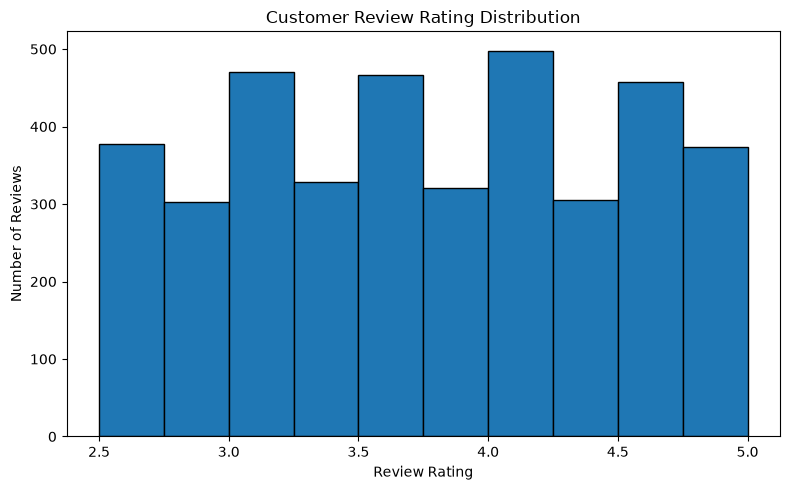

In [57]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["review_rating"],
    bins=10,
    edgecolor="black"
)

plt.title("Customer Review Rating Distribution")
plt.xlabel("Review Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.savefig("../screenshots/review_rating_distribution.png", dpi=300)

plt.show()

In [58]:
# Final EDA Summary

total_customers = len(df)
total_revenue = df["purchase_amount"].sum()
average_purchase = df["purchase_amount"].mean()
average_rating = df["review_rating"].mean()

print("CUSTOMER SHOPPING BEHAVIOR - EDA SUMMARY")
print("-" * 50)
print(f"Total Customers      : {total_customers:,}")
print(f"Total Revenue        : ${total_revenue:,.2f}")
print(f"Average Purchase     : ${average_purchase:,.2f}")
print(f"Average Review Rating: {average_rating:.2f}")
print(f"Unique Categories    : {df['category'].nunique()}")
print(f"Unique Products      : {df['item_purchased'].nunique()}")
print(f"Unique Locations     : {df['location'].nunique()}")

CUSTOMER SHOPPING BEHAVIOR - EDA SUMMARY
--------------------------------------------------
Total Customers      : 3,900
Total Revenue        : $233,081.00
Average Purchase     : $59.76
Average Review Rating: 3.75
Unique Categories    : 4
Unique Products      : 25
Unique Locations     : 50
